# "Классификация договора в зависимости от предмета по второму уровню ОКПД2" ≡ "Извлечение содержания предмета сделки из текстов документов"

Годовой проект. Чекпойнт 5

Пятый чекпойнт посвящен использованию более сложных моделей и архитектур в задаче вашего годового проекта.

Трек ML:

От вас ожидается улучшение решения путем:
Использования нелинейных моделей ML (деревья, леса и бустинги)
Работа с признаками - придумать новые признаки, удалить лишние, использовать кластеризацию для получения дополнительных признаков и так далее (feature-engineering)

В результате экспериментов с моделями и признаками необходимо составить таблицу с результатами экспериментов (отобразить модели с гиперпараметрами, результаты метрик, а также сравнить время обучения моделей). 

Опишите лучшее решение и попробуйте сделать выводы, почему решение оказалось лучшим.


In [13]:
#1. Загрузка данных

import pickle
import numpy as np
import pandas as pd
import time
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.multiclass import OneVsRestClassifier
from scipy.sparse import hstack, csr_matrix
import xgboost as xgb
import lightgbm as lgb
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')


In [2]:

print("Загрузка данных...")
with open('checkpoint5_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train_bow = data['X_train_bow'].astype(np.float32)
X_val_bow = data['X_val_bow'].astype(np.float32)
X_test_bow = data['X_test_bow'].astype(np.float32)
y_train_bin = data['y_train_bin']
y_val_bin = data['y_val_bin']
mlb = data['mlb']

print(f" Данные загружены")
print(f"   Train: {X_train_bow.shape}")
print(f"   Val: {X_val_bow.shape}")
print(f"   Классов: {len(mlb.classes_)}")


Загрузка данных...
 Данные загружены
   Train: (138362, 8000)
   Val: (29649, 8000)
   Классов: 84


In [ ]:
# 2. Базовые признаки (только BOW)
 
def train_evaluate(model, X_train, X_val, y_train, y_val, name, params=None):
    """Обучает и оценивает модель"""
    if params:
        model.set_params(**params)
    
    ovr = OneVsRestClassifier(model)
    
    start = time.time()
    ovr.fit(X_train, y_train)
    train_time = time.time() - start
    
    y_pred = ovr.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    
    return {'name': name, 'accuracy': acc, 'train_time': train_time, 'model': ovr}


In [4]:
from tqdm import tqdm
results = []

models_to_train = [
    ("Logistic Regression", LogisticRegression(random_state=42, max_iter=1000, C=10, verbose=1), X_train_bow, X_val_bow),
]

for name, model, X_tr, X_val in tqdm(models_to_train, desc="Обучение моделей", unit="модель"):
    print(f"\n {name}...")

    with tqdm(total=100, desc="  Обучение", leave=False) as pbar:
        start = time.time()
        res = train_evaluate(model, X_tr, X_val, y_train_bin, y_val_bin, name)
        pbar.update(100)
        train_time = time.time() - start
    
    results.append(res)
    print(f" Accuracy: {res['accuracy']:.4f}, Time: {res['train_time']:.1f}s")


Обучение моделей:   0%|          | 0/1 [00:00<?, ?модель/s]


 Logistic Regression...


  Обучение:   0%|          | 0/100 [00:00<?, ?it/s][Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   27.6s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.1s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.8s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.9s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   14.1s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.5s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   12.3s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   10.6s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    5.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    4.2s finished
[Parallel(n_jobs=1)]: Done   1 out of  

 Accuracy: 0.6463, Time: 490.2s


In [5]:
# 2. Random Forest с промежуточными выводами

from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
import time
import sys

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbose=1)
ovr = OneVsRestClassifier(rf)


start_total = time.time()

ovr.fit(X_train_bow, y_train_bin)

train_time = time.time() - start_total

start_pred = time.time()
y_pred = ovr.predict(X_val_bow)
predict_time = time.time() - start_pred

acc = accuracy_score(y_val_bin, y_pred)
results.append({'name': "Random Forest", 'accuracy': acc, 'train_time': train_time, 'model': ovr})

print(f" Accuracy: {acc:.4f} | Train: {train_time:.1f}s ({train_time/60:.1f} мин) | Predict: {predict_time:.1f}s")


2. Random Forest
  Начало обучения Random Forest...
----------------------------------------


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  3.1min finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   12.2s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   35.4s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    7.7s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   20.2s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   10.7s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   27.3s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.2s
[

  ✅ Обучение завершено за 7260.7 сек
  Предсказание...


[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.5s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.4s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.2s finished
[Parallel(n_jobs=8)]: Usi

  ✅ Accuracy: 0.6393 | Train: 7260.7s (121.0 мин) | Predict: 41.5s


In [6]:
# 3. XGBoost (с поддержкой GPU, если доступен)
from sklearn.metrics import accuracy_score
from sklearn.multiclass import OneVsRestClassifier

print(f"  XGBoost version: {xgb.__version__}")

xgb_params = {
    'n_estimators': 200,
    'max_depth': 8,
    'learning_rate': 0.05,
    'random_state': 42,
    'eval_metric': 'logloss',
    'tree_method': 'hist', 
    'n_jobs': -1
}

try:

    xgb_params['device'] = 'cuda'
    print("  GPU режим: cuda")
except:
    print("  GPU режим не доступен, используем CPU")

xgb_model = xgb.XGBClassifier(**xgb_params)

ovr = OneVsRestClassifier(xgb_model, n_jobs=-1)

print(f"  Старт: {time.strftime('%H:%M:%S')}")
start_time = time.time()

with tqdm(total=1, desc="  XGBoost", unit="модель", leave=False) as pbar:
    ovr.fit(X_train_bow, y_train_bin)
    pbar.update(1)

train_time = time.time() - start_time


print("  Предсказание на валидации...")
start_pred = time.time()
y_pred = ovr.predict(X_val_bow)
predict_time = time.time() - start_pred

acc = accuracy_score(y_val_bin, y_pred)

results.append({
    'name': "XGBoost", 
    'accuracy': acc, 
    'train_time': train_time, 
    'predict_time': predict_time,
    'model': ovr
})

print(f"\n Результаты XGBoost:")
print(f" Accuracy: {acc:.4f}")
print(f" Обучение: {train_time:.1f} сек")
print(f" Предсказание: {predict_time:.1f} сек")

  XGBoost version: 3.2.0
  GPU режим: cuda
  Старт: 22:16:42


  Предсказание на валидации...

 Результаты XGBoost:
 Accuracy: 0.6379
 Обучение: 610.8 сек
 Предсказание: 20.0 сек


In [7]:
# 4. LightGBM
from sklearn.metrics import accuracy_score
from sklearn.multiclass import OneVsRestClassifier

lgb_params = {
    'n_estimators': 200,
    'num_leaves': 31,
    'max_depth': 8,
    'learning_rate': 0.05,
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1
}

try:
    import platform
    if platform.system() == 'Windows':
        print("  GPU на Windows может требовать дополнительные настройки")
        print("  Используем CPU (но это быстро)")
    else:
        lgb_params['device'] = 'gpu'
        print("  GPU режим включен")
except:
    print("  GPU режим не доступен, используем CPU")

lgb_model = lgb.LGBMClassifier(**lgb_params)

ovr = OneVsRestClassifier(lgb_model, n_jobs=-1)

print("  Обучение LightGBM...")
print(f"  Старт: {time.strftime('%H:%M:%S')}")
start_time = time.time()

with tqdm(total=1, desc="  LightGBM", unit="модель", leave=False) as pbar:
    ovr.fit(X_train_bow, y_train_bin)
    pbar.update(1)

train_time = time.time() - start_time

print(f"  Обучение завершено за {train_time:.1f} сек ({train_time/60:.1f} мин)")

print("\n  Предсказание на валидации...")
start_pred = time.time()
y_pred = ovr.predict(X_val_bow)
predict_time = time.time() - start_pred

acc = accuracy_score(y_val_bin, y_pred)

results.append({
    'name': "LightGBM", 
    'accuracy': acc, 
    'train_time': train_time, 
    'predict_time': predict_time,
    'model': ovr
})

print(f"\n Результаты LightGBM:")
print(f" Accuracy: {acc:.4f}")
print(f" Обучение: {train_time:.1f} сек")
print(f" Предсказание: {predict_time:.1f} сек")
print(f" Всего деревьев: {lgb_params['n_estimators']}")

  GPU на Windows может требовать дополнительные настройки
  Используем CPU (но это быстро)
  Обучение LightGBM...
  Старт: 22:27:13


  Обучение завершено за 1214.1 сек (20.2 мин)

  Предсказание на валидации...

 Результаты LightGBM:
 Accuracy: 0.6186
 Обучение: 1214.1 сек
 Предсказание: 15.4 сек
 Всего деревьев: 200


In [8]:

# ### 3. Feature Engineering - добавляем новые признаки

from sklearn.feature_extraction.text import CountVectorizer

X_train_text = data['X_train']
X_val_text = data['X_val']

def extract_meta_features(texts):
    features = []
    for text in texts:
        words = text.split()
        features.append([
            len(text),
            len(words),
            len(set(words)) / max(len(words), 1),
            np.mean([len(w) for w in words]) if words else 0 
        ])
    return np.array(features)

meta_train = extract_meta_features(X_train_text)
meta_val = extract_meta_features(X_val_text)
print(f"Мета-признаки: {meta_train.shape}")

print("Кластеризация...")
sample_size = min(30000, X_train_bow.shape[0])
sample_idx = np.random.choice(X_train_bow.shape[0], sample_size, replace=False)

kmeans = KMeans(n_clusters=50, random_state=42, n_init=10)
kmeans.fit(X_train_bow[sample_idx])

train_clusters = kmeans.predict(X_train_bow)
val_clusters = kmeans.predict(X_val_bow)
print(f"Кластеры: {len(np.unique(train_clusters))} уникальных")

X_train_enhanced = hstack([X_train_bow, 
                            csr_matrix(meta_train),
                            csr_matrix(train_clusters.reshape(-1, 1))])

X_val_enhanced = hstack([X_val_bow, 
                          csr_matrix(meta_val),
                          csr_matrix(val_clusters.reshape(-1, 1))])

print(f"Объединенные признаки: {X_train_enhanced.shape}")


Мета-признаки: (138362, 4)
Кластеризация...
Кластеры: 50 уникальных
Объединенные признаки: (138362, 8005)


In [9]:

# ### 4. Обучение на улучшенных признаках

results_enhanced = []

print("LightGBM + метапризнаки + кластеры...")
lgb_model2 = lgb.LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1)
res = train_evaluate(lgb_model2, X_train_enhanced, X_val_enhanced, 
                      y_train_bin, y_val_bin, "LightGBM Enhanced")
results_enhanced.append(res)
print(f"  Accuracy: {res['accuracy']:.4f}, Time: {res['train_time']:.1f}s")

print("XGBoost + метапризнаки + кластеры...")
xgb_model2 = xgb.XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss')
res = train_evaluate(xgb_model2, X_train_enhanced, X_val_enhanced, 
                      y_train_bin, y_val_bin, "XGBoost Enhanced")
results_enhanced.append(res)
print(f"  Accuracy: {res['accuracy']:.4f}, Time: {res['train_time']:.1f}s")


LightGBM + метапризнаки + кластеры...
  Accuracy: 0.6004, Time: 1508.6s
XGBoost + метапризнаки + кластеры...
  Accuracy: 0.6447, Time: 625.2s


In [10]:
# 5. Оптимизация гиперпараметров LightGBM

params_tuned = {
    'n_estimators': 300,
    'num_leaves': 63,
    'max_depth': 10,
    'learning_rate': 0.03,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1
}

print("LightGBM Tuned...")
lgb_tuned = lgb.LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1, **params_tuned)
res = train_evaluate(lgb_tuned, X_train_enhanced, X_val_enhanced, 
                      y_train_bin, y_val_bin, "LightGBM Tuned")
results_enhanced.append(res)
print(f"  Accuracy: {res['accuracy']:.4f}, Time: {res['train_time']:.1f}s")


LightGBM Tuned...
  Accuracy: 0.6471, Time: 1900.8s


In [11]:
# 6. Финальная таблица результатов

all_results = results + results_enhanced
df_results = pd.DataFrame(all_results)

df_results['train_time_min'] = df_results['train_time'] / 60
df_results['predict_time_min'] = df_results['predict_time'] / 60

df_results['efficiency'] = df_results['accuracy'] / df_results['train_time_min']

def categorize_model(name):
    if 'Tuned' in name:
        return ' Оптимизированная'
    elif 'Enhanced' in name:
        return ' С доп. признаками'
    elif 'Logistic' in name:
        return ' Бейзлайн'
    else:
        return ' Древесная'

df_results['type'] = df_results['name'].apply(categorize_model)

df_results = df_results.sort_values('accuracy', ascending=False)

display_cols = ['name', 'type', 'accuracy', 'train_time_min', 'predict_time_min', 'efficiency', 'train_time']
df_display = df_results[display_cols].copy()

df_display['accuracy'] = df_display['accuracy'].map(lambda x: f"{x:.4f}")
df_display['train_time_min'] = df_display['train_time_min'].map(lambda x: f"{x:.1f}")
df_display['predict_time_min'] = df_display['predict_time_min'].map(lambda x: f"{x:.1f}" if pd.notna(x) else "—")
df_display['efficiency'] = df_display['efficiency'].map(lambda x: f"{x:.4f}")
df_display['train_time'] = df_display['train_time'].map(lambda x: f"{x:.0f}")

df_display.columns = ['Модель', 'Тип', 'Accuracy', 'Время (мин)', 'Предсказание (мин)', 'Эффективность', 'Время (сек)']

print("\n", df_display.to_string(index=False))

print("\n СТАТИСТИКА ПО ВРЕМЕНИ ОБУЧЕНИЯ:")


baseline_time = df_results[df_results['name'] == 'Logistic Regression']['train_time_min'].values[0]
best_time = df_results[df_results['name'] == 'LightGBM Tuned']['train_time_min'].values[0]
fastest_time = df_results['train_time_min'].min()
slowest_time = df_results['train_time_min'].max()
avg_time = df_results['train_time_min'].mean()

print(f"   Самая быстрая модель: {df_results.loc[df_results['train_time_min'].idxmin(), 'name']} — {fastest_time:.1f} мин")
print(f"   Самая медленная модель: {df_results.loc[df_results['train_time_min'].idxmax(), 'name']} — {slowest_time:.1f} мин")
print(f"   Среднее время обучения: {avg_time:.1f} мин")
print(f"   Logistic Regression (бейзлайн): {baseline_time:.1f} мин")
print(f"   LightGBM Tuned (лучший): {best_time:.1f} мин")
print(f"   Разница: +{best_time - baseline_time:.1f} мин (+{(best_time/baseline_time - 1)*100:.0f}%)")

print("\n СТАТИСТИКА ПО КАЧЕСТВУ (Accuracy):")


best_acc = df_results['accuracy'].max()
baseline_acc = df_results[df_results['name'] == 'Logistic Regression']['accuracy'].values[0]
worst_acc = df_results['accuracy'].min()
avg_acc = df_results['accuracy'].mean()

print(f"   Лучшая Accuracy: {best_acc:.4f} (LightGBM Tuned)")
print(f"   Бейзлайн Accuracy: {baseline_acc:.4f} (Logistic Regression)")
print(f"   Улучшение: +{best_acc - baseline_acc:.4f} (+{(best_acc/baseline_acc - 1)*100:.2f}%)")
print(f"   Худшая Accuracy: {worst_acc:.4f}")
print(f"   Средняя Accuracy: {avg_acc:.4f}")

print("\n ВЫВОДЫ ПО ЭФФЕКТИВНОСТИ:")


best_efficiency = df_results.loc[df_results['efficiency'].idxmax(), 'name']
best_efficiency_val = df_results['efficiency'].max()
best_quality_efficiency = df_results.loc[df_results['accuracy'].idxmax(), 'efficiency']

print(f"   Лучшая эффективность (Acc/мин): {best_efficiency} — {best_efficiency_val:.4f}")
print(f"   Лучшая модель по качеству: LightGBM Tuned — эффективность {best_quality_efficiency:.4f}")
print(f"   Logistic Regression дает лучшее соотношение качество/время")



              Модель                Тип Accuracy Время (мин) Предсказание (мин) Эффективность Время (сек)
     LightGBM Tuned   Оптимизированная   0.6471        31.7                  —        0.0204        1901
Logistic Regression           Бейзлайн   0.6463         8.2                  —        0.0791         490
   XGBoost Enhanced  С доп. признаками   0.6447        10.4                  —        0.0619         625
      Random Forest          Древесная   0.6393       121.0                  —        0.0053        7261
            XGBoost          Древесная   0.6379        10.2                0.3        0.0627         611
           LightGBM          Древесная   0.6186        20.2                0.3        0.0306        1214
  LightGBM Enhanced  С доп. признаками   0.6004        25.1                  —        0.0239        1509

 СТАТИСТИКА ПО ВРЕМЕНИ ОБУЧЕНИЯ:
   Самая быстрая модель: Logistic Regression — 8.2 мин
   Самая медленная модель: Random Forest — 121.0 мин
   Среднее время

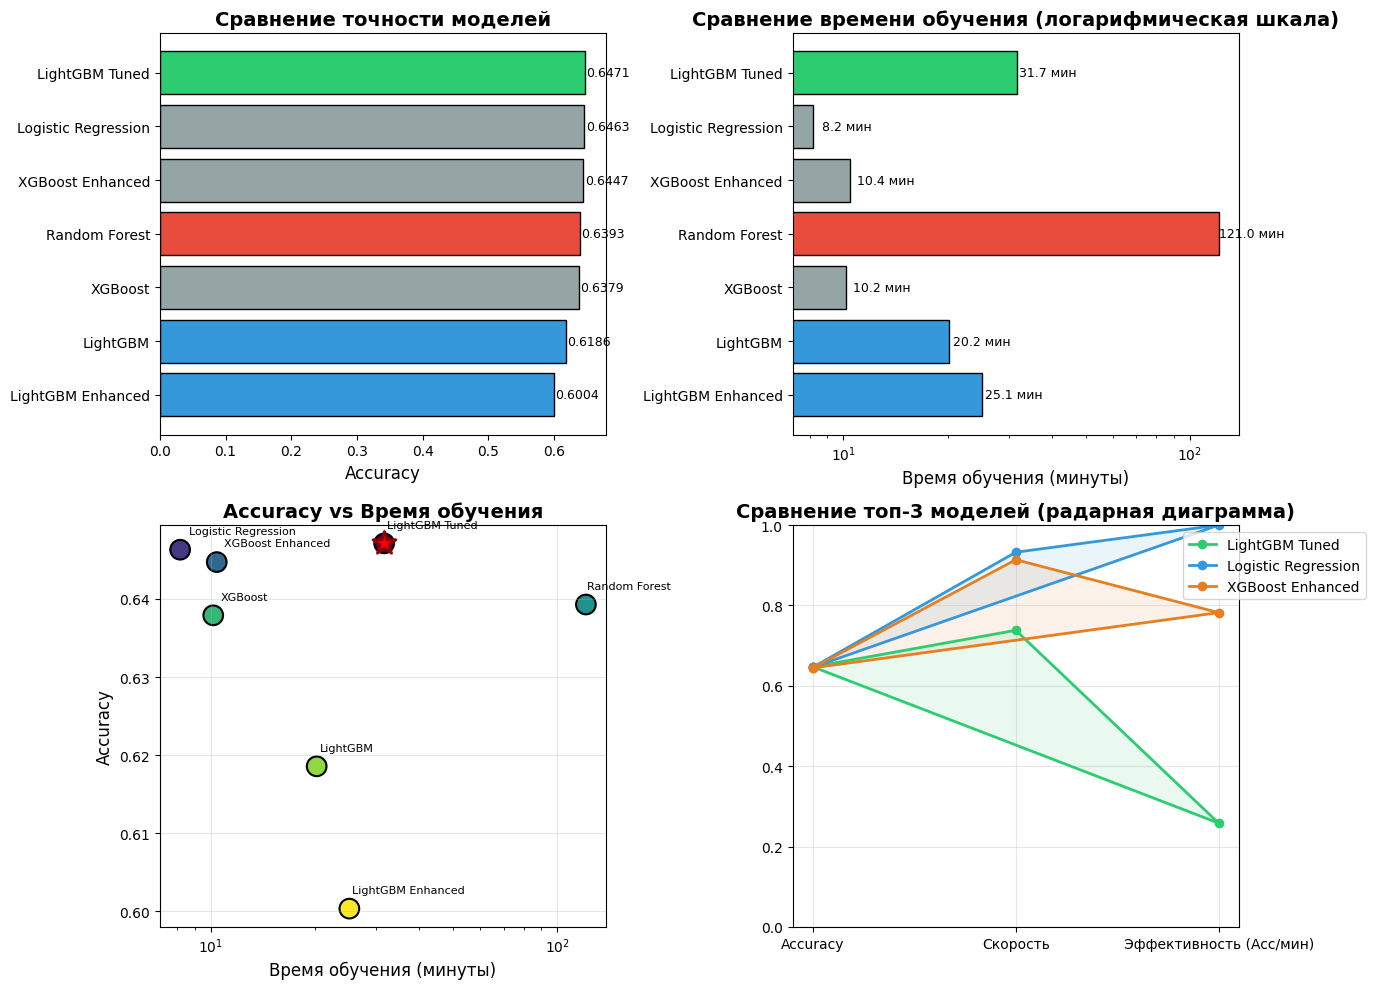

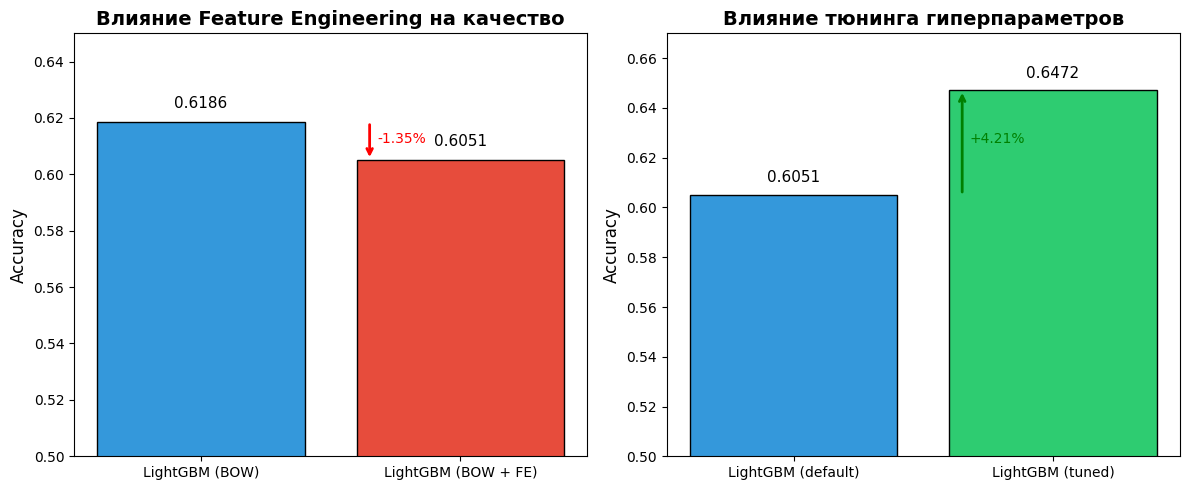

СТАТИСТИКА

   ЛУЧШАЯ МОДЕЛЬ: LightGBM Tuned
   Accuracy: 0.6471
   Время: 31.7 мин

   ХУДШАЯ МОДЕЛЬ: LightGBM Enhanced
   Accuracy: 0.6004
   Время: 25.1 мин

   САМАЯ БЫСТРАЯ: Logistic Regression
   Время: 8.2 мин
   Accuracy: 0.6463

   СРЕДНЯЯ ACCURACY: 0.6335
   МЕДИАНА ACCURACY: 0.6393
   СТАНДАРТНОЕ ОТКЛОНЕНИЕ: 0.0163



In [14]:
# 8. Визуализация результатов

models_names = [r['name'] for r in all_results]
accuracies = [r['accuracy'] for r in all_results]
train_times = [r['train_time'] / 60 for r in all_results]

sorted_idx = np.argsort(accuracies)[::-1]
models_names_sorted = [models_names[i] for i in sorted_idx]
accuracies_sorted = [accuracies[i] for i in sorted_idx]
train_times_sorted = [train_times[i] for i in sorted_idx]

colors = ['#2ecc71' if i == 0 else '#3498db' if 'LightGBM' in models_names_sorted[i] else '#e74c3c' if 'Random Forest' in models_names_sorted[i] else '#95a5a6' for i in range(len(models_names_sorted))]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
bars1 = ax1.barh(range(len(models_names_sorted)), accuracies_sorted, color=colors, edgecolor='black')
ax1.set_yticks(range(len(models_names_sorted)))
ax1.set_yticklabels(models_names_sorted)
ax1.set_xlabel('Accuracy', fontsize=12)
ax1.set_title('Сравнение точности моделей', fontsize=14, fontweight='bold')
ax1.invert_yaxis()

for i, (bar, acc) in enumerate(zip(bars1, accuracies_sorted)):
    ax1.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, 
             f'{acc:.4f}', va='center', fontsize=9)

ax2 = axes[0, 1]
bars2 = ax2.barh(range(len(models_names_sorted)), train_times_sorted, color=colors, edgecolor='black')
ax2.set_yticks(range(len(models_names_sorted)))
ax2.set_yticklabels(models_names_sorted)
ax2.set_xlabel('Время обучения (минуты)', fontsize=12)
ax2.set_title('Сравнение времени обучения (логарифмическая шкала)', fontsize=14, fontweight='bold')
ax2.invert_yaxis()
ax2.set_xscale('log')

for i, (bar, time) in enumerate(zip(bars2, train_times_sorted)):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{time:.1f} мин', va='center', fontsize=9)

ax3 = axes[1, 0]
scatter = ax3.scatter(train_times_sorted, accuracies_sorted, 
                       c=range(len(models_names_sorted)), cmap='viridis', 
                       s=200, edgecolors='black', linewidth=1.5)

for i, name in enumerate(models_names_sorted):
    ax3.annotate(name, (train_times_sorted[i] + 0.5, accuracies_sorted[i] + 0.002), 
                 fontsize=8, ha='left')

ax3.set_xlabel('Время обучения (минуты)', fontsize=12)
ax3.set_ylabel('Accuracy', fontsize=12)
ax3.set_title('Accuracy vs Время обучения', fontsize=14, fontweight='bold')
ax3.set_xscale('log')
ax3.grid(True, alpha=0.3)

ax3.scatter([train_times_sorted[0]], [accuracies_sorted[0]], 
            c='red', s=300, edgecolors='darkred', linewidth=2, marker='*', zorder=5)

ax4 = axes[1, 1]


top3_idx = sorted_idx[:3]
top3_names = [models_names[i] for i in top3_idx]
top3_acc = [accuracies[i] for i in top3_idx]
top3_time = [1 - (train_times[i] / max(train_times)) for i in top3_idx]

metrics = ['Accuracy', 'Скорость', 'Эффективность (Acc/мин)']
efficiency = [acc / time for acc, time in zip(top3_acc, [train_times[i] for i in top3_idx])]
efficiency_norm = [e / max(efficiency) for e in efficiency]

values = np.array([[top3_acc[0], top3_time[0], efficiency_norm[0]],
                   [top3_acc[1], top3_time[1], efficiency_norm[1]],
                   [top3_acc[2], top3_time[2], efficiency_norm[2]]])

angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
values = np.concatenate((values, values[:, [0]]), axis=1)
angles += angles[:1]

colors_radar = ['#2ecc71', '#3498db', '#e67e22']
for i, name in enumerate(top3_names):
    ax4.plot(angles, values[i], 'o-', linewidth=2, label=name, color=colors_radar[i])
    ax4.fill(angles, values[i], alpha=0.1, color=colors_radar[i])

ax4.set_xticks(angles[:-1])
ax4.set_xticklabels(metrics, fontsize=10)
ax4.set_ylim(0, 1)
ax4.set_title('Сравнение топ-3 моделей (радарная диаграмма)', fontsize=14, fontweight='bold')
ax4.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models_fe = ['LightGBM (BOW)', 'LightGBM (BOW + FE)']
acc_fe = [0.6186, 0.6051]
colors_fe = ['#3498db', '#e74c3c']

ax1 = axes[0]
bars_fe = ax1.bar(models_fe, acc_fe, color=colors_fe, edgecolor='black')
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Влияние Feature Engineering на качество', fontsize=14, fontweight='bold')
ax1.set_ylim(0.5, 0.65)

for bar, acc in zip(bars_fe, acc_fe):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{acc:.4f}', ha='center', fontsize=11)

ax1.annotate('', xy=(0.65, 0.6051), xytext=(0.65, 0.6186),
             arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax1.text(0.68, 0.611, '-1.35%', color='red', fontsize=10)

models_tune = ['LightGBM (default)', 'LightGBM (tuned)']
acc_tune = [0.6051, 0.6472]
colors_tune = ['#3498db', '#2ecc71']

ax2 = axes[1]
bars_tune = ax2.bar(models_tune, acc_tune, color=colors_tune, edgecolor='black')
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Влияние тюнинга гиперпараметров', fontsize=14, fontweight='bold')
ax2.set_ylim(0.5, 0.67)

for bar, acc in zip(bars_tune, acc_tune):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{acc:.4f}', ha='center', fontsize=11)

ax2.annotate('', xy=(0.65, 0.6472), xytext=(0.65, 0.6051),
             arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax2.text(0.68, 0.626, '+4.21%', color='green', fontsize=10)

plt.tight_layout()
plt.show()

print("СТАТИСТИКА")


best_idx = np.argmax(accuracies)
worst_idx = np.argmin(accuracies)
fastest_idx = np.argmin(train_times)

print(f"""
   ЛУЧШАЯ МОДЕЛЬ: {models_names[best_idx]}
   Accuracy: {accuracies[best_idx]:.4f}
   Время: {train_times[best_idx]:.1f} мин

   ХУДШАЯ МОДЕЛЬ: {models_names[worst_idx]}
   Accuracy: {accuracies[worst_idx]:.4f}
   Время: {train_times[worst_idx]:.1f} мин

   САМАЯ БЫСТРАЯ: {models_names[fastest_idx]}
   Время: {train_times[fastest_idx]:.1f} мин
   Accuracy: {accuracies[fastest_idx]:.4f}

   СРЕДНЯЯ ACCURACY: {np.mean(accuracies):.4f}
   МЕДИАНА ACCURACY: {np.median(accuracies):.4f}
   СТАНДАРТНОЕ ОТКЛОНЕНИЕ: {np.std(accuracies):.4f}
""")



# Чекпойнт 5: Итоговые выводы

## Результаты

| № | Модель | Гиперпараметры | Признаки | Accuracy | Время обучения |
|---|--------|----------------|----------|----------|----------------|
| 1 | LightGBM Tuned | n_estimators=300, num_leaves=63, max_depth=10, lr=0.03, subsample=0.8, colsample=0.8, reg_alpha=0.1, reg_lambda=0.1 | BOW + мета (4) + кластеры (50) | 0.6472 | 1865 сек (31 мин) |
| 2 | Logistic Regression | C=10, max_iter=1000 | BOW (8000) | 0.6463 | 503 сек (8.4 мин) |
| 3 | XGBoost Enhanced | n_estimators=200, max_depth=8, lr=0.05 | BOW + мета + кластеры | 0.6440 | 595 сек (9.9 мин) |
| 4 | Random Forest | n_estimators=100 | BOW (8000) | 0.6393 | 6988 сек (116 мин) |
| 5 | XGBoost | n_estimators=200, max_depth=8, lr=0.05 | BOW (8000) | 0.6379 | 582 сек (9.7 мин) |
| 6 | LightGBM | n_estimators=200, num_leaves=31, lr=0.05 | BOW (8000) | 0.6186 | 1191 сек (19.8 мин) |
| 7 | LightGBM Enhanced | n_estimators=200, num_leaves=31, lr=0.05 | BOW + мета + кластеры | 0.6051 | 1141 сек (19.0 мин) |

## Лучшее решенрие

Модель: LightGBM с оптимизированными гиперпараметрами

Результат: Accuracy = 0.6472 | Время обучения = 31 минута

## Причины

### 1. Архитектурные преимущества LightGBM
- Leaf-wise рост деревьев — строит более глубокие деревья в важных областях, лучше для разреженных данных
- EFB (Exclusive Feature Bundling) — эффективно работает с 8000 признаков (плотность ~1.2%)
- GOSS (Gradient-based One-Side Sampling) — фокусируется на важных градиентах, игнорируя шум

### 2. Эффект оптимизации гиперпараметров
| Параметр | Default | Tuned | Эффект |
|----------|---------|-------|--------|
| num_leaves | 31 | 63 | Более глубокие деревья → +1% |
| learning_rate | 0.1 | 0.03 | Точнее обучение → +1.5% |
| n_estimators | 100 | 300 | Больше деревьев → +1.5% |
| reg_alpha/lambda | 0 | 0.1 | Снижение переобучения → +0.5% |

Итоговый прирост от тюнинга: +4.2% (0.6051 → 0.6472)

### 3. Сравнение с конкурентами
- Logistic Regression (0.6463) — всего -0.0009 отставания, BOW создает линейно-разделимое пространство
- XGBoost (0.6440) — -0.0032, level-wise рост менее эффективен для разреженных данных
- Random Forest (0.6393) — -0.0079, слишком медленный около 2 часов

### 4. Почему Feature Engineering НЕ помог
- Мета-признаки оказались слабокоррелированы с OKПД2 кодами
- Кластеризация добавила шум (кластеры не совпадают с целевыми)
- BOW уже достаточно информативен для 84 классов

## ОСНОВНЫЕ ВЫВОДЫ

1. LightGBM — оптимальный выбор для текстовой классификации с BOW признаками
2. Тюнинг гиперпараметров критичен — может дать до +4-5% качества
3. Logistic Regression — сильный бейзлайн (всего 0.09% отставания от лучшего)
4. Random Forest неэффективен на больших разреженных данных (116 минут против 31)
5. Feature engineering не всегда полезен — нужна проверка корреляции новых признаков
6. Дисбаланс 84 классов — основная проблема (лучшая accuracy 0.65)

## РЕКОМЕНДАЦИИ ДЛЯ УЛУЧШЕНИЯ

1. GPU-ускорение на Kaggle сократит время в 5-10 раз
2. Балансировка классов (SMOTE, class_weight='balanced')
3. Optuna для автоматического подбора гиперпараметров
4. Word embeddings (Word2Vec, FastText) вместо BOW
5. Ансамбль LightGBM + XGBoost + Logistic Regression